In [10]:
import os
import numpy as np
import pandas as pd
import pickle
import json
from os import path
from pathlib import Path

os.makedirs('results/img/', exist_ok=True)
np.random.seed(1234)

project_root = Path(path.join(os.getcwd(), '../')).resolve().as_posix()
project_root

'/Applications/Development/MyStuff/learning-tsp'

In [11]:
from tqdm import tqdm
import os

filename = os.path.join(project_root,"data/tsp/tsp10-200_concorde_with_side_100.txt")
filename2 = os.path.join(project_root, "data/tsp/tsp10-200_concorde_with_side_100_solved_2.txt")

with open(filename, "r") as file:
    total_lines = sum(1 for _ in file)

with open(filename2, "r") as file:
    total_lines2 = sum(1 for _ in file)

assert total_lines == total_lines2
print(f"Total lines in the files: {total_lines}")

Total lines in the files: 25600


In [14]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"({self.x}, {self.y})"
    
    def distance(self, other):
        return ((self.x - other.x) ** 2 + (self.y - other.y) ** 2) ** 0.5
    
    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

In [15]:
import pandas as pd

num_nodes_col = []
tour_length1_col = []
tour_length2_col = []


f1_lines = open(filename, "r").readlines()
f2_lines = open(filename2, "r").readlines()

def extract_data_from_line(line):
    line = line.split(" ")
    num_nodes = int(line.index('output') // 2)
    cities_points = [Point(float(line[idx]), float(line[idx + 1])) for idx in range(0, 2 * num_nodes, 2)]
    tour_nodes = [int(node) - 1 for node in line[line.index('output') + 1:-1]]
    tour_length = sum(
        cities_points[tour_nodes[i]].distance(cities_points[tour_nodes[i + 1]])
        for i in range(len(tour_nodes) - 1)
    )
    return num_nodes, cities_points, tour_nodes, tour_length

for line1, line2 in zip(f1_lines, f2_lines):
    num_nodes1, cities_points1, tour_nodes1, tour_length1 = extract_data_from_line(line1)
    num_nodes2, cities_points2, tour_nodes2, tour_length2 = extract_data_from_line(line2)

    assert cities_points1 == cities_points2
    assert num_nodes1 == num_nodes2
    
    num_nodes_col.append(num_nodes1)
    tour_length1_col.append(tour_length1)
    tour_length2_col.append(tour_length2)


base_df = pd.DataFrame({
    "num_nodes": num_nodes_col,
    "tour_length1": tour_length1_col,
    "tour_length2": tour_length2_col,
})
base_df

,num_nodes,tour_length1,tour_length2
0,10,313.724362,272.836129
1,10,270.217060,270.217060
2,10,384.441124,314.186246
3,10,317.375601,312.502256
4,10,323.490178,308.839647
...,...,...,...
25595,200,1491.932360,1153.053829
25596,200,1521.377849,1126.860038
25597,200,1629.356142,1143.669992
25598,200,1475.229500,1125.564339


<Axes: xlabel='num_nodes', ylabel='tour_length2'>

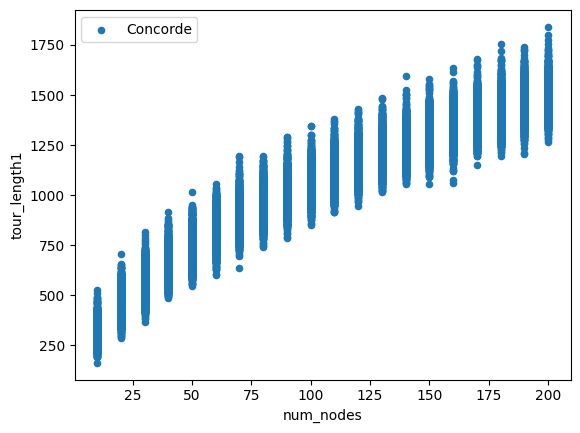

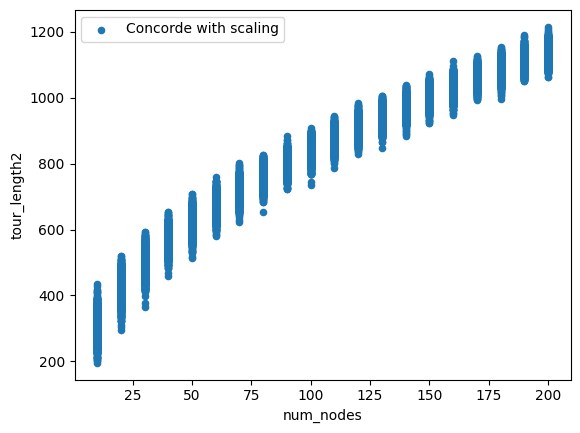

In [19]:
base_df.plot(x="num_nodes", y="tour_length1", kind="scatter", label="Concorde")
base_df.plot(x="num_nodes", y="tour_length2", kind="scatter", label="Concorde with scaling")
# plt.legend()
# plt.show()